# Project title:

## Prediction of LC-MS Retention Time Using Molecular Descriptors

## Overall objective:

#### Build a machine learning model that predicts the retention time of molecules using their molecular descriptors.

> ## Section 1: Data Loading and Initial Inspection

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

In [45]:
df= pd.read_csv(r'E:\Data Science\Projects\Kaggel\LCMS Retention Time\ret_times.csv')
df.head()

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,rt
0,12.990628,-0.335181,12.990628,0.035905,0.760602,414.333,389.133,413.127297,148,0,0.409110,-0.452734,0.452734,0.409110,1.111111,1.851852,2.518519,35.498262,10.077395,2.339028,-2.419428,2.235730,-2.594557,6.415298,-0.135196,1.700079,694.777490,19.388541,15.495677,17.007535,12.973566,9.263002,10.018930,7.089956,7.904357,5.242886,5.981916,3.823819,4.144507,-1.50,1.563337e+06,20.239835,9.128099,5.061983,169.486611,19.436592,0.000000,0.000000,5.90718,0.000000,6.093240,4.794537,4.794537,0.0,0.0,29.268247,43.627342,26.179026,29.617727,14.325937,35.202300,0.0,14.699729,0.0,25.304306,46.378336,33.807819,0.0,0.000000,0.000000,4.794537,0.000000,23.20188,79.120326,15.952222,0.0,18.405095,18.199101,10.045267,0.000000,0.0,53.09,0.000000,9.589074,0.0,24.463082,29.679536,25.197721,19.951441,17.032644,10.966277,4.899910,27.938743,4.866526,12.034984,30.889882,0.928298,0.837704,0.043613,5.239555,2.304626,4.355197,1.388505,0.578947,27,0,6,0,2,2,1,0,1,4,0,8,4,0,2,2,3,2.9109,105.3190,687.8
1,12.609649,-3.521975,12.609649,0.030555,0.702317,369.487,342.271,369.172227,140,0,0.254647,-0.495842,0.495842,0.254647,1.400000,2.120000,2.720000,32.227873,10.126662,2.252824,-2.228088,2.290642,-2.396906,7.911293,0.093789,2.241239,733.653662,18.612520,15.040497,15.856993,11.834066,8.560923,10.213188,6.128408,8.375080,4.695141,6.478895,3.195197,4.221653,-1.80,3.722757e+05,19.523748,8.052660,4.243965,148.989987,15.787319,5.749512,9.837253,0.00000,5.907180,0.000000,9.694447,8.417797,0.0,0.0,13.847474,31.997523,18.652964,29.008972,17.949197,21.431819,0.0,10.216698,0.0,37.626442,38.230588,17.696186,0.0,5.749512,15.787319,5.687386,5.749512,0.00000,57.763648,9.837253,0.0,37.047106,17.028218,0.000000,0.000000,0.0,101.73,9.837253,13.212334,0.0,33.555866,12.586597,25.931156,26.166269,0.000000,0.000000,17.140436,10.470530,29.588389,0.000000,14.905944,2.899815,6.111130,-0.172068,3.020843,2.167577,6.157750,-2.096047,0.588235,25,3,7,0,1,1,1,0,1,6,2,8,7,0,1,1,2,1.2851,97.7354,590.7
2,11.164259,-0.177407,11.164259,0.137593,0.610213,161.160,154.104,161.047678,60,0,0.255444,-0.507307,0.507307,0.255444,1.166667,2.000000,2.750000,16.255222,10.147495,1.992592,-1.967387,2.194991,-2.031291,5.862884,0.481362,3.045081,473.157384,8.552042,6.242213,6.242213,5.787694,3.582431,3.582431,2.545169,2.545169,1.792163,1.792163,1.204616,1.204616,-1.77,7.373362e+02,6.910660,2.373364,0.870558,68.288471,10.090506,5.749512,0.000000,0.00000,5.559267,0.000000,4.794537,0.000000,0.0,0.0,6.066367,18.199101,11.583068,5.386224,5.106527,10.772448,0.0,4.983979,0.0,0.00

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77901 entries, 0 to 77900
Columns: 124 entries, MaxEStateIndex to rt
dtypes: float64(105), int64(19)
memory usage: 73.7 MB


In [47]:
df.describe()

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,rt
count,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.00000,77901.0,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,7.790100e+04,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.0,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.0,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.00000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000
mean,12.398119,-1.074155,12.398119,0.123069,0.684043,384.342535,362.490113,383.934342,141.91330,0.0,0.274125,-0.404168,0.406483,0.271810,1.141699,1.895992,2.604826,27.274360,10.065138,2.262067,-2.230114,2.283634,-2.343944,6.752827,0.029788,1.637807,957.378349,19.185300,15.350470,15.916416,13.118886,9.011554,9.648989,6.745117,7.501824,4.794188,5.471743,3.321860,3.880362,-2.726331,3.053931e+07,18.313592,7.669670,3.859279,160.383699,12.494735,8.446816,3.846534,6.649863,4.153431,1.797431,7.621037,7.153251,2.907757,3.060424,21.694853,39.597737,28.342013,12.593301,12.908653,22.350736,0.066357,14.243241,2.437098,26.599787,20.047094,54.313795,0.0,7.392424,8.996735,6.247522,2.624158,5.436486,38.964742,11.887996,6.703468,26.563566,43.702549,0.819032,8.412931,0.0,74.547068,5.988492,9.692951,0.005072,15.047922,23.484136,25.332234,12.079479,17.753749,25.940125,18.254882,6.780141,15.574103,1.484776,21.638712,5.720371,2.193670,0.46

In [48]:
df.shape

(77901, 124)

In [49]:
df.columns

Index(['MaxEStateIndex', 'MinEStateIndex', 'MaxAbsEStateIndex', 'MinAbsEStateIndex', 'qed', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons',
       ...
       'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumSaturatedHeterocycles', 'NumSaturatedRings', 'RingCount', 'MolLogP', 'MolMR', 'rt'], dtype='object', length=124)

In [50]:
print(df.columns.tolist())

['MaxEStateIndex', 'MinEStateIndex', 'MaxAbsEStateIndex', 'MinAbsEStateIndex', 'qed', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA11', 'Slo

In [51]:
df.dtypes

MaxEStateIndex       float64
MinEStateIndex       float64
MaxAbsEStateIndex    float64
MinAbsEStateIndex    float64
qed                  float64
                      ...   
NumSaturatedRings      int64
RingCount              int64
MolLogP              float64
MolMR                float64
rt                   float64
Length: 124, dtype: object

In [52]:
df.isnull().sum()

MaxEStateIndex       0
MinEStateIndex       0
MaxAbsEStateIndex    0
MinAbsEStateIndex    0
qed                  0
                    ..
NumSaturatedRings    0
RingCount            0
MolLogP              0
MolMR                0
rt                   0
Length: 124, dtype: int64

In [53]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values.head(5)

MaxEStateIndex    0
SlogP_VSA7        0
EState_VSA8       0
EState_VSA7       0
EState_VSA6       0
dtype: int64

In [54]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)

missing_percentage.head(5)

MaxEStateIndex    0.0
SlogP_VSA7        0.0
EState_VSA8       0.0
EState_VSA7       0.0
EState_VSA6       0.0
dtype: float64

In [55]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(by="Missing Percentage", ascending=False)

missing_summary.head(5)

,Missing Count,Missing Percentage
MaxEStateIndex,0,0.0
SlogP_VSA7,0,0.0
EState_VSA8,0,0.0
EState_VSA7,0,0.0
EState_VSA6,0,0.0


In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [58]:
df.describe(include="all")

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,rt
count,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.00000,77901.0,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,7.790100e+04,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.0,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.0,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.00000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000,77901.000000
mean,12.398119,-1.074155,12.398119,0.123069,0.684043,384.342535,362.490113,383.934342,141.91330,0.0,0.274125,-0.404168,0.406483,0.271810,1.141699,1.895992,2.604826,27.274360,10.065138,2.262067,-2.230114,2.283634,-2.343944,6.752827,0.029788,1.637807,957.378349,19.185300,15.350470,15.916416,13.118886,9.011554,9.648989,6.745117,7.501824,4.794188,5.471743,3.321860,3.880362,-2.726331,3.053931e+07,18.313592,7.669670,3.859279,160.383699,12.494735,8.446816,3.846534,6.649863,4.153431,1.797431,7.621037,7.153251,2.907757,3.060424,21.694853,39.597737,28.342013,12.593301,12.908653,22.350736,0.066357,14.243241,2.437098,26.599787,20.047094,54.313795,0.0,7.392424,8.996735,6.247522,2.624158,5.436486,38.964742,11.887996,6.703468,26.563566,43.702549,0.819032,8.412931,0.0,74.547068,5.988492,9.692951,0.005072,15.047922,23.484136,25.332234,12.079479,17.753749,25.940125,18.254882,6.780141,15.574103,1.484776,21.638712,5.720371,2.193670,0.46

> ## Section 2: Data Cleaning and Preprocessing

In [59]:
df_clean = df.copy()

In [60]:
for i, col in enumerate(df_clean.columns):
    print(i, col)

0 MaxEStateIndex
1 MinEStateIndex
2 MaxAbsEStateIndex
3 MinAbsEStateIndex
4 qed
5 MolWt
6 HeavyAtomMolWt
7 ExactMolWt
8 NumValenceElectrons
9 NumRadicalElectrons
10 MaxPartialCharge
11 MinPartialCharge
12 MaxAbsPartialCharge
13 MinAbsPartialCharge
14 FpDensityMorgan1
15 FpDensityMorgan2
16 FpDensityMorgan3
17 BCUT2D_MWHI
18 BCUT2D_MWLOW
19 BCUT2D_CHGHI
20 BCUT2D_CHGLO
21 BCUT2D_LOGPHI
22 BCUT2D_LOGPLOW
23 BCUT2D_MRHI
24 BCUT2D_MRLOW
25 BalabanJ
26 BertzCT
27 Chi0
28 Chi0n
29 Chi0v
30 Chi1
31 Chi1n
32 Chi1v
33 Chi2n
34 Chi2v
35 Chi3n
36 Chi3v
37 Chi4n
38 Chi4v
39 HallKierAlpha
40 Ipc
41 Kappa1
42 Kappa2
43 Kappa3
44 LabuteASA
45 PEOE_VSA1
46 PEOE_VSA10
47 PEOE_VSA11
48 PEOE_VSA12
49 PEOE_VSA13
50 PEOE_VSA14
51 PEOE_VSA2
52 PEOE_VSA3
53 PEOE_VSA4
54 PEOE_VSA5
55 PEOE_VSA6
56 PEOE_VSA7
57 PEOE_VSA8
58 PEOE_VSA9
59 SMR_VSA1
60 SMR_VSA10
61 SMR_VSA2
62 SMR_VSA3
63 SMR_VSA4
64 SMR_VSA5
65 SMR_VSA6
66 SMR_VSA7
67 SMR_VSA8
68 SMR_VSA9
69 SlogP_VSA1
70 SlogP_VSA10
71 SlogP_VSA11
72 SlogP_VSA12


In [72]:
df_clean["rt_min"] = (df_clean["rt"] / 60).round(3)
df_clean[["rt_min"]].head()

,rt_min
0,11.463
1,9.845
2,9.727
3,9.650
4,10.052


In [73]:
target_col = "rt_min"

In [74]:
print(df_clean.shape)

(77901, 125)


In [75]:
df_clean['rt_min'].isnull().sum()

np.int64(0)

> ## Section 3: Exploratory Data Analysis


In [76]:
target_col = "rt_min"

df_clean[target_col].describe()

count    77901.000000
mean        13.476682
std          2.911698
min          2.932000
25%         11.148000
50%         12.997000
75%         15.283000
max         24.528000
Name: rt_min, dtype: float64

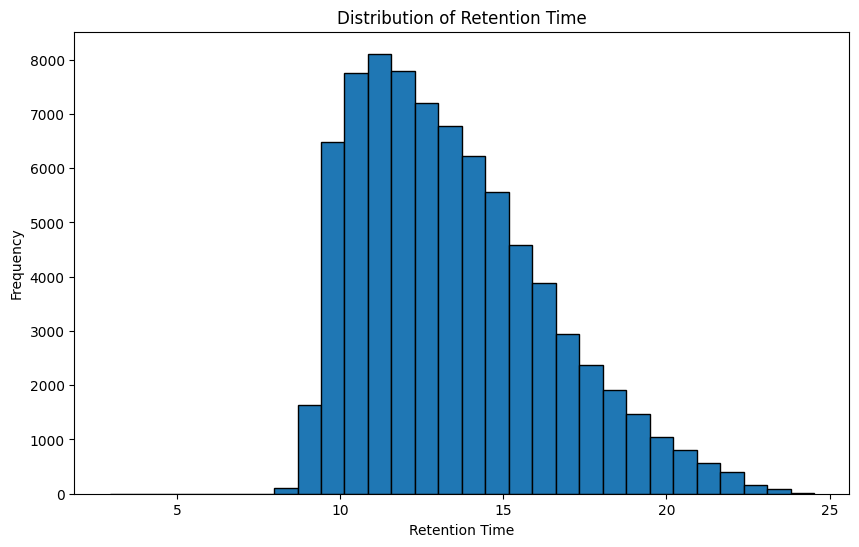

In [77]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean[target_col].dropna(), bins=30, edgecolor='k')
plt.xlabel("Retention Time")
plt.ylabel("Frequency")
plt.title("Distribution of Retention Time")
plt.show()

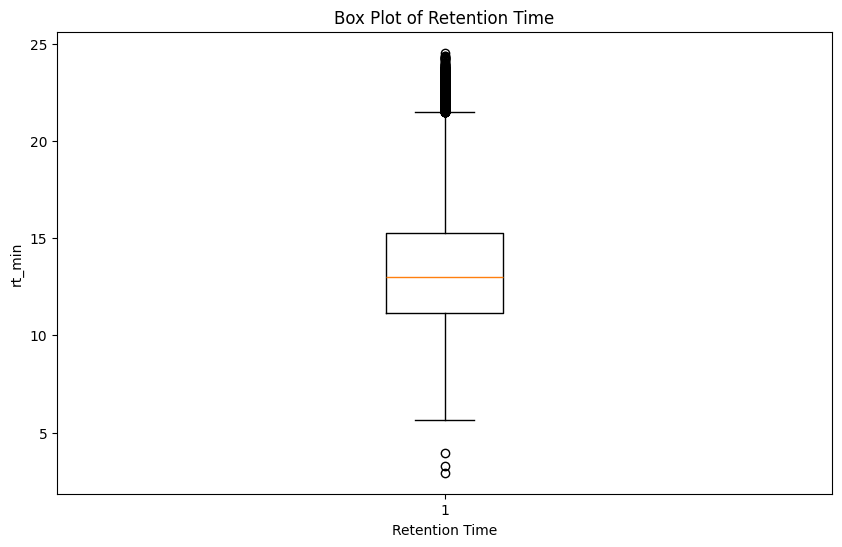

In [80]:
plt.figure(figsize=(10, 6))
plt.boxplot(df_clean[target_col].dropna())
plt.xlabel("Retention Time")
plt.ylabel("rt_min")
plt.title("Box Plot of Retention Time")
plt.show()

In [81]:
# Calculate IQR and identify outliers

Q1 = df_clean[target_col].quantile(0.25)
Q3 = df_clean[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean[target_col] < lower_bound) |
    (df_clean[target_col] > upper_bound)
]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of potential RT outliers:", outliers.shape[0])
print("Percentage of potential RT outliers:", round(outliers.shape[0] / len(df_clean) * 100, 2), "%")

Lower bound: 4.9455
Upper bound: 21.4855
Number of potential RT outliers: 768
Percentage of potential RT outliers: 0.99 %


In [82]:
corr_with_rt = df_clean.corr()[target_col].sort_values(ascending=False)

corr_with_rt.head(20)

rt_min                    1.000000
rt                        1.000000
MolLogP                   0.512212
NumAromaticCarbocycles    0.380441
BertzCT                   0.341972
NumAromaticRings          0.338224
SlogP_VSA6                0.329345
SMR_VSA9                  0.325657
PEOE_VSA6                 0.320308
SMR_VSA7                  0.318440
VSA_EState6               0.298342
SlogP_VSA8                0.298231
HeavyAtomMolWt            0.248956
BCUT2D_LOGPLOW            0.227240
MolWt                     0.222925
ExactMolWt                0.222222
SlogP_VSA12               0.219852
VSA_EState1               0.202151
VSA_EState10              0.200884
BCUT2D_CHGLO              0.194757
Name: rt_min, dtype: float64

In [83]:
corr_with_rt.tail(20)

FpDensityMorgan2           -0.168475
VSA_EState7                -0.177342
FpDensityMorgan1           -0.190786
HallKierAlpha              -0.190985
NumHDonors                 -0.201673
PEOE_VSA2                  -0.204221
PEOE_VSA1                  -0.206956
NHOHCount                  -0.207376
NumAliphaticRings          -0.214850
NumSaturatedRings          -0.227395
NumAliphaticHeterocycles   -0.233102
NumSaturatedHeterocycles   -0.246775
PEOE_VSA8                  -0.273705
SMR_VSA6                   -0.295497
FractionCSP3               -0.309459
qed                        -0.315569
SlogP_VSA2                 -0.340061
NumRadicalElectrons              NaN
SMR_VSA8                         NaN
SlogP_VSA9                       NaN
Name: rt_min, dtype: float64

In [84]:
corr_table = pd.DataFrame({
    "feature": corr_with_rt.index,
    "correlation_with_rt": corr_with_rt.values
})

corr_table["absolute_correlation"] = corr_table["correlation_with_rt"].abs()

corr_table = corr_table.sort_values(
    by="absolute_correlation",
    ascending=False
)

corr_table.head(30)

,feature,correlation_with_rt,absolute_correlation
0,rt_min,1.000000,1.000000
1,rt,1.000000,1.000000
2,MolLogP,0.512212,0.512212
3,NumAromaticCarbocycles,0.380441,0.380441
4,BertzCT,0.341972,0.341972
121,SlogP_VSA2,-0.340061,0.340061
5,NumAromaticRings,0.338224,0.338224
6,SlogP_VSA6,0.329345,0.329345
7,SMR_VSA9,0.325657,0.325657
8,PEOE_VSA6,0.320308,0.320308


In [88]:
corr_table_no_target = corr_table[corr_table["feature"] != target_col]
corr_table_no_target.head(5)



,feature,correlation_with_rt,absolute_correlation
1,rt,1.000000,1.000000
2,MolLogP,0.512212,0.512212
3,NumAromaticCarbocycles,0.380441,0.380441
4,BertzCT,0.341972,0.341972
121,SlogP_VSA2,-0.340061,0.340061


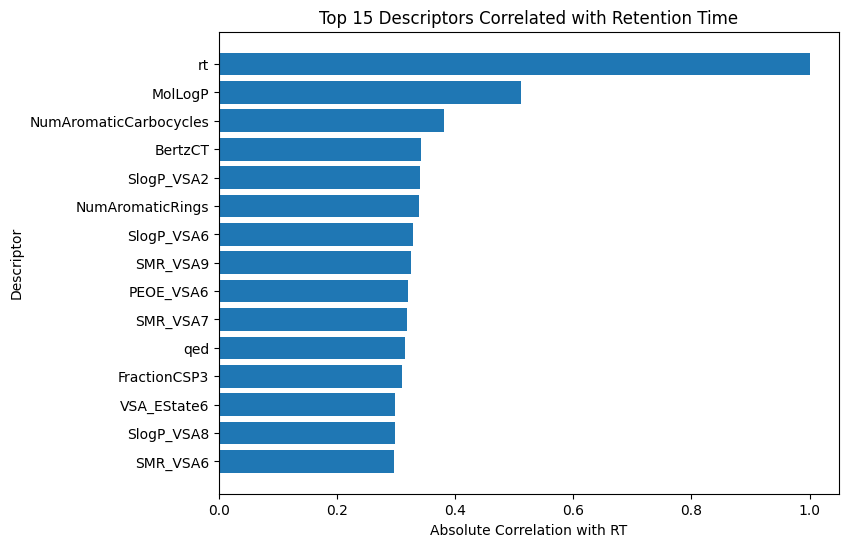

In [90]:
top_corr = corr_table_no_target.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_corr["feature"], top_corr["absolute_correlation"])
plt.xlabel("Absolute Correlation with RT")
plt.ylabel("Descriptor")
plt.title("Top 15 Descriptors Correlated with Retention Time")
plt.gca().invert_yaxis()
plt.show()

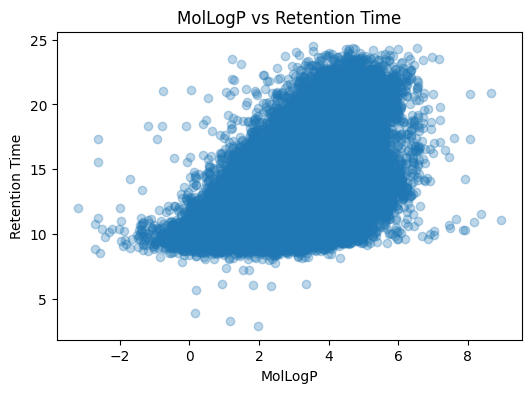

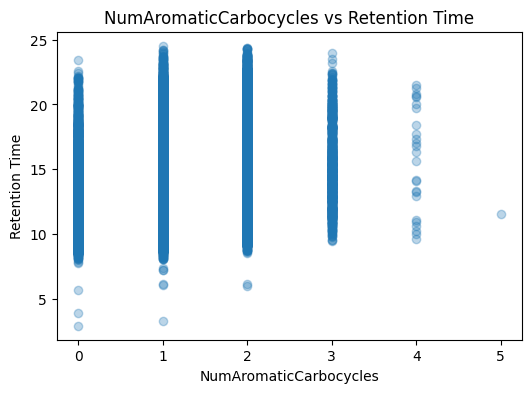

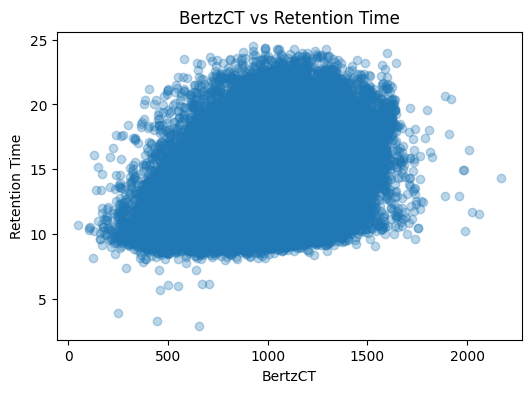

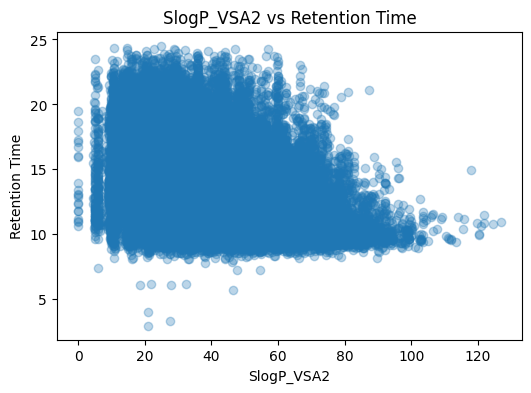

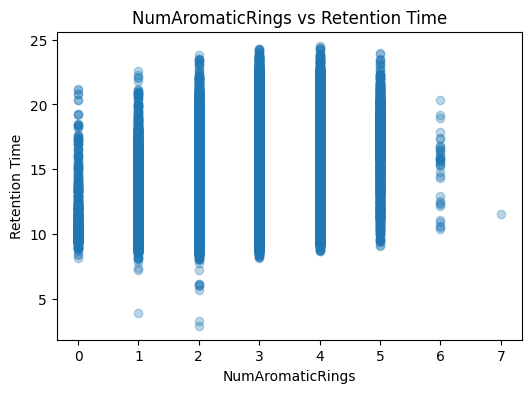

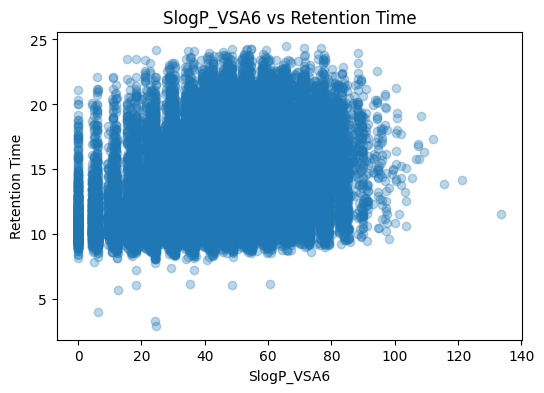

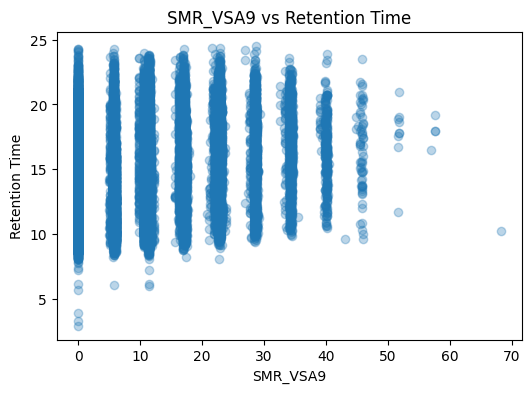

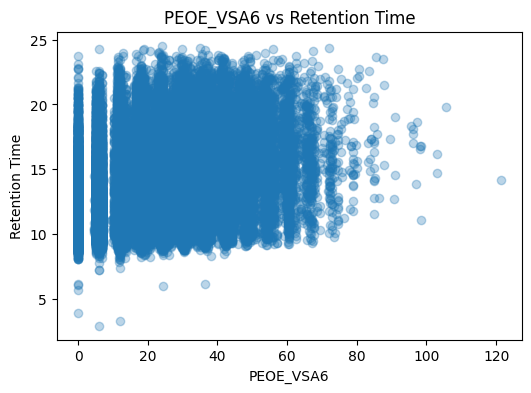

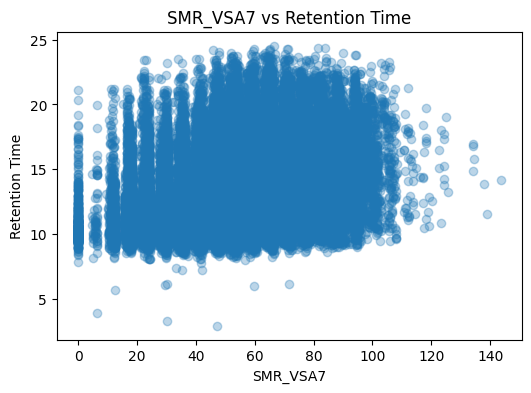

In [92]:
top_features = corr_table_no_target["feature"].iloc[1:10].tolist()

for feature in top_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_clean[feature], df_clean[target_col], alpha=0.3)
    plt.xlabel(feature)
    plt.ylabel("Retention Time")
    plt.title(f"{feature} vs Retention Time")
    plt.show()

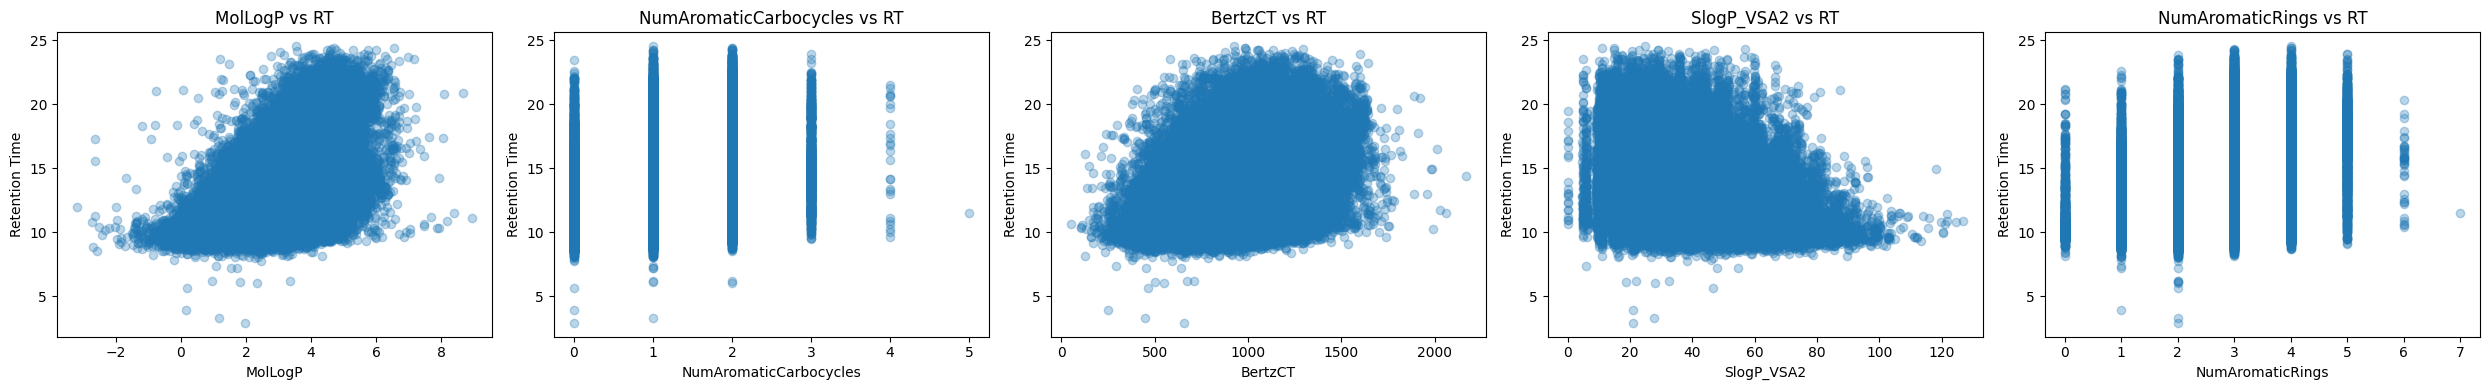

In [95]:
top_features = corr_table_no_target["feature"].iloc[1:6].tolist()

fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for i, feature in enumerate(top_features):
    axes[i].scatter(df_clean[feature], df_clean[target_col], alpha=0.3)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Retention Time")
    axes[i].set_title(f"{feature} vs RT")

plt.tight_layout()
plt.show()

In [97]:
feature_cols = [col for col in df_clean.columns if col != target_col]

corr_matrix = df_clean[feature_cols].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []

for col in upper_triangle.columns:
    high_corr_features = upper_triangle.index[upper_triangle[col] > 0.95].tolist()
    for row in high_corr_features:
        high_corr_pairs.append((row, col, upper_triangle.loc[row, col]))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["feature_1", "feature_2", "correlation"]
)

high_corr_df = high_corr_df.sort_values(by="correlation", ascending=False)

high_corr_df.head(30)

,feature_1,feature_2,correlation
0,MaxEStateIndex,MaxAbsEStateIndex,1.000000
2,MolWt,ExactMolWt,0.999992
43,Chi1,HeavyAtomCount,0.996950
1,MolWt,HeavyAtomMolWt,0.996288
3,HeavyAtomMolWt,ExactMolWt,0.996133
40,Chi0,HeavyAtomCount,0.990468
44,LabuteASA,HeavyAtomCount,0.988417
8,NumValenceElectrons,Chi0,0.987311
37,Chi1,LabuteASA,0.985231
26,Chi3v,Chi4v,0.982957


In [98]:
print("Number of descriptor pairs with correlation > 0.95:")
print(high_corr_df.shape[0])

Number of descriptor pairs with correlation > 0.95:
51


> ## Section 4: Feature Selection and Feature Engineering

In [103]:
non_numeric_cols = df_clean.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("Non-numeric columns:")
print(non_numeric_cols)

Non-numeric columns:
[]


In [105]:
df_numeric = df_clean.drop(columns=["rt"], errors="ignore")
df_numeric.shape

(77901, 124)

In [106]:
print("rt" in df_numeric.columns)
print("rt_min" in df_numeric.columns)

False
True


In [109]:
# Remove columns with constant values

constant_cols = [
    col for col in df_numeric.columns
    if df_numeric[col].nunique() <= 1
]

print("Number of constant columns:", len(constant_cols))
print(constant_cols)

Number of constant columns: 3
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9']


In [110]:
df_numeric = df_numeric.drop(columns=constant_cols)

print(df_numeric.shape)

(77901, 121)


In [111]:
X_all = df_numeric.drop(columns=[target_col])
y = df_numeric[target_col]

print("X_all shape:", X_all.shape)
print("y shape:", y.shape)

X_all shape: (77901, 120)
y shape: (77901,)


In [113]:
# Remove highly correlated descriptors

corr_threshold = 0.95

corr_matrix = X_all.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

features_to_drop_corr = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > corr_threshold)
]

print("Number of highly correlated features to drop:", len(features_to_drop_corr))
print(features_to_drop_corr)

Number of highly correlated features to drop: 22
['MaxAbsEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'Kappa1', 'LabuteASA', 'HeavyAtomCount', 'NumHDonors', 'MolMR']


In [114]:
X_reduced = X_all.drop(columns=features_to_drop_corr)

print("X_all shape:", X_all.shape)
print("X_reduced shape:", X_reduced.shape)

X_all shape: (77901, 120)
X_reduced shape: (77901, 98)


In [115]:
all_feature_names = X_all.columns.tolist()
reduced_feature_names = X_reduced.columns.tolist()

print("Number of all features:", len(all_feature_names))
print("Number of reduced features:", len(reduced_feature_names))

Number of all features: 120
Number of reduced features: 98


In [116]:
print("Final dataset check:")
print("X_all:", X_all.shape)
print("X_reduced:", X_reduced.shape)
print("y:", y.shape)

print("\nTarget summary:")
print(y.describe())

Final dataset check:
X_all: (77901, 120)
X_reduced: (77901, 98)
y: (77901,)

Target summary:
count    77901.000000
mean        13.476682
std          2.911698
min          2.932000
25%         11.148000
50%         12.997000
75%         15.283000
max         24.528000
Name: rt_min, dtype: float64


> ## Section 5: Train-Test Split and Feature Scaling

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [118]:
X_all_train, X_all_test, y_train, y_test = train_test_split(
    X_all,
    y,
    test_size=0.2,
    random_state=42
)

In [119]:
print("X_all_train:", X_all_train.shape)
print("X_all_test:", X_all_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_all_train: (62320, 120)
X_all_test: (15581, 120)
y_train: (62320,)
y_test: (15581,)


In [120]:
X_reduced_train, X_reduced_test, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

In [121]:
print("X_reduced_train:", X_reduced_train.shape)
print("X_reduced_test:", X_reduced_test.shape)
print("y_train_reduced:", y_train_reduced.shape)
print("y_test_reduced:", y_test_reduced.shape)

X_reduced_train: (62320, 98)
X_reduced_test: (15581, 98)
y_train_reduced: (62320,)
y_test_reduced: (15581,)


In [122]:
scaler_all = StandardScaler()

X_all_train_scaled = scaler_all.fit_transform(X_all_train)
X_all_test_scaled = scaler_all.transform(X_all_test)

> **Important:**

>> fit_transform() --> is used only on the training data.

>> transform() --> is used on the test data.

>> This avoids data leakage.

In [124]:
X_all_train_scaled = pd.DataFrame(
    X_all_train_scaled,
    columns=X_all_train.columns,
    index=X_all_train.index
)

X_all_test_scaled = pd.DataFrame(
    X_all_test_scaled,
    columns=X_all_test.columns,
    index=X_all_test.index
)

In [125]:
scaler_reduced = StandardScaler()

X_reduced_train_scaled = scaler_reduced.fit_transform(X_reduced_train)
X_reduced_test_scaled = scaler_reduced.transform(X_reduced_test)

In [126]:
X_reduced_train_scaled = pd.DataFrame(
    X_reduced_train_scaled,
    columns=X_reduced_train.columns,
    index=X_reduced_train.index
)

X_reduced_test_scaled = pd.DataFrame(
    X_reduced_test_scaled,
    columns=X_reduced_test.columns,
    index=X_reduced_test.index
)

In [127]:
# Fial check 

print("All features:")
print("X_all_train:", X_all_train.shape)
print("X_all_test:", X_all_test.shape)
print("X_all_train_scaled:", X_all_train_scaled.shape)
print("X_all_test_scaled:", X_all_test_scaled.shape)

print("\nReduced features:")
print("X_reduced_train:", X_reduced_train.shape)
print("X_reduced_test:", X_reduced_test.shape)
print("X_reduced_train_scaled:", X_reduced_train_scaled.shape)
print("X_reduced_test_scaled:", X_reduced_test_scaled.shape)

print("\nTarget:")
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

All features:
X_all_train: (62320, 120)
X_all_test: (15581, 120)
X_all_train_scaled: (62320, 120)
X_all_test_scaled: (15581, 120)

Reduced features:
X_reduced_train: (62320, 98)
X_reduced_test: (15581, 98)
X_reduced_train_scaled: (62320, 98)
X_reduced_test_scaled: (15581, 98)

Target:
y_train: (62320,)
y_test: (15581,)


> ## Section 6: Baseline Model Training and Comparison

In this section, we will train and compare these regression models:

Linear Regression  
Ridge Regression  
Random Forest Regressor  
Extra Trees Regressor  
HistGradientBoostingRegressor  
XGBoost Regressor  

> MAE   = Mean Absolute Error  
> RMSE  = Root Mean Squared Error  
> R²    = Coefficient of Determination  

>> **Lower MAE/RMSE is better. Higher R² is better.**

In [128]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [129]:
try:
    from xgboost import XGBRegressor
    xgboost_available = True
except ImportError:
    xgboost_available = False
    print("XGBoost is not installed. We will skip XGBRegressor.")

In [130]:
# Create evaluation function

def evaluate_regression_model(model_name, model, X_train, X_test, y_train, y_test):
    """
    Train a regression model and return evaluation metrics.
    """
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [131]:
# Define models

# For Linear Regression and Ridge Regression, use scaled data.

# For tree-based models, use unscaled data.

linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0)
}

tree_models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42,
        max_iter=200
    )
}

if xgboost_available:
    tree_models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

In [132]:
# Train models on all features

results_all = []

# Linear models on scaled all-feature data
for model_name, model in linear_models.items():
    result = evaluate_regression_model(
        model_name=model_name + " - All Features",
        model=model,
        X_train=X_all_train_scaled,
        X_test=X_all_test_scaled,
        y_train=y_train,
        y_test=y_test
    )
    results_all.append(result)

# Tree-based models on unscaled all-feature data
for model_name, model in tree_models.items():
    result = evaluate_regression_model(
        model_name=model_name + " - All Features",
        model=model,
        X_train=X_all_train,
        X_test=X_all_test,
        y_train=y_train,
        y_test=y_test
    )
    results_all.append(result)

results_all_df = pd.DataFrame(results_all)
results_all_df = results_all_df.sort_values(by="RMSE")

results_all_df

,Model,MAE,RMSE,R2
3,Extra Trees - All Features,0.918800,1.380752,0.776528
4,Hist Gradient Boosting - All Features,0.971773,1.382407,0.775992
5,XGBoost - All Features,0.980107,1.399606,0.770383
2,Random Forest - All Features,0.976562,1.422078,0.762951
0,Linear Regression - All Features,1.404343,1.864997,0.592293
1,Ridge Regression - All Features,1.421776,1.882101,0.584781


In [133]:
# Train models using reduced features

results_reduced = []

# Linear models on scaled reduced-feature data
for model_name, model in linear_models.items():
    result = evaluate_regression_model(
        model_name=model_name + " - Reduced Features",
        model=model,
        X_train=X_reduced_train_scaled,
        X_test=X_reduced_test_scaled,
        y_train=y_train,
        y_test=y_test
    )
    results_reduced.append(result)

# Tree-based models on unscaled reduced-feature data
for model_name, model in tree_models.items():
    result = evaluate_regression_model(
        model_name=model_name + " - Reduced Features",
        model=model,
        X_train=X_reduced_train,
        X_test=X_reduced_test,
        y_train=y_train,
        y_test=y_test
    )
    results_reduced.append(result)

results_reduced_df = pd.DataFrame(results_reduced)
results_reduced_df = results_reduced_df.sort_values(by="RMSE")

results_reduced_df

,Model,MAE,RMSE,R2
3,Extra Trees - Reduced Features,0.916443,1.377644,0.777533
4,Hist Gradient Boosting - Reduced Features,0.975348,1.387892,0.774211
5,XGBoost - Reduced Features,0.985748,1.403588,0.769075
2,Random Forest - Reduced Features,0.973911,1.419425,0.763834
0,Linear Regression - Reduced Features,1.435987,1.897278,0.578057
1,Ridge Regression - Reduced Features,1.436193,1.897328,0.578035


In [134]:
results_df = pd.concat([results_all_df, results_reduced_df], ignore_index=True)

results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

results_df.round(4)

,Model,MAE,RMSE,R2
0,Extra Trees - Reduced Features,0.9164,1.3776,0.7775
1,Extra Trees - All Features,0.9188,1.3808,0.7765
2,Hist Gradient Boosting - All Features,0.9718,1.3824,0.7760
3,Hist Gradient Boosting - Reduced Features,0.9753,1.3879,0.7742
4,XGBoost - All Features,0.9801,1.3996,0.7704
5,XGBoost - Reduced Features,0.9857,1.4036,0.7691
6,Random Forest - Reduced Features,0.9739,1.4194,0.7638
7,Random Forest - All Features,0.9766,1.4221,0.7630
8,Linear Regression - All Features,1.4043,1.8650,0.5923
9,Ridge Regression - All Features,1.4218,1.8821,0.5848


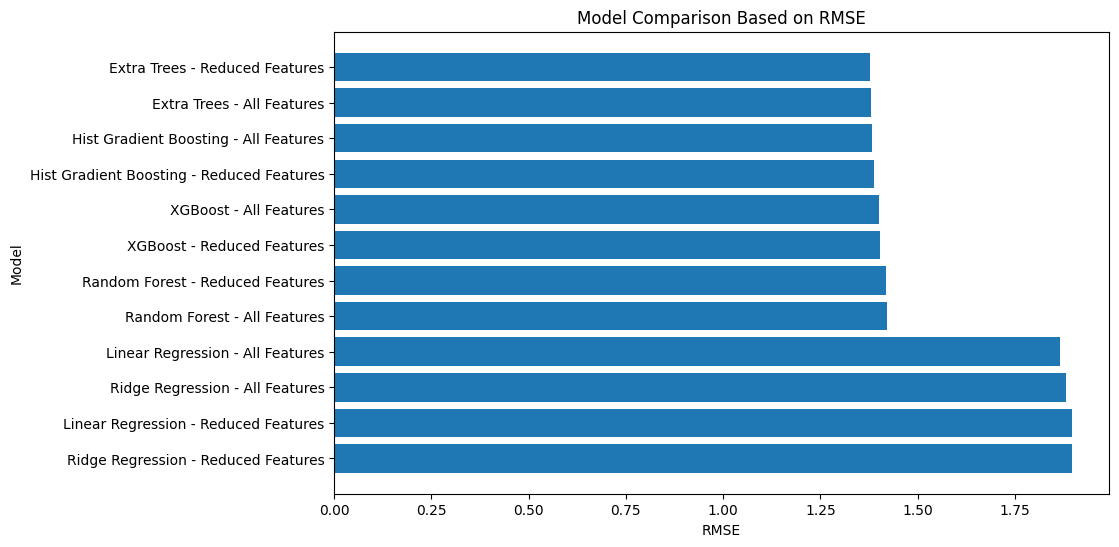

In [135]:
plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["RMSE"])
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.title("Model Comparison Based on RMSE")
plt.gca().invert_yaxis()
plt.show()

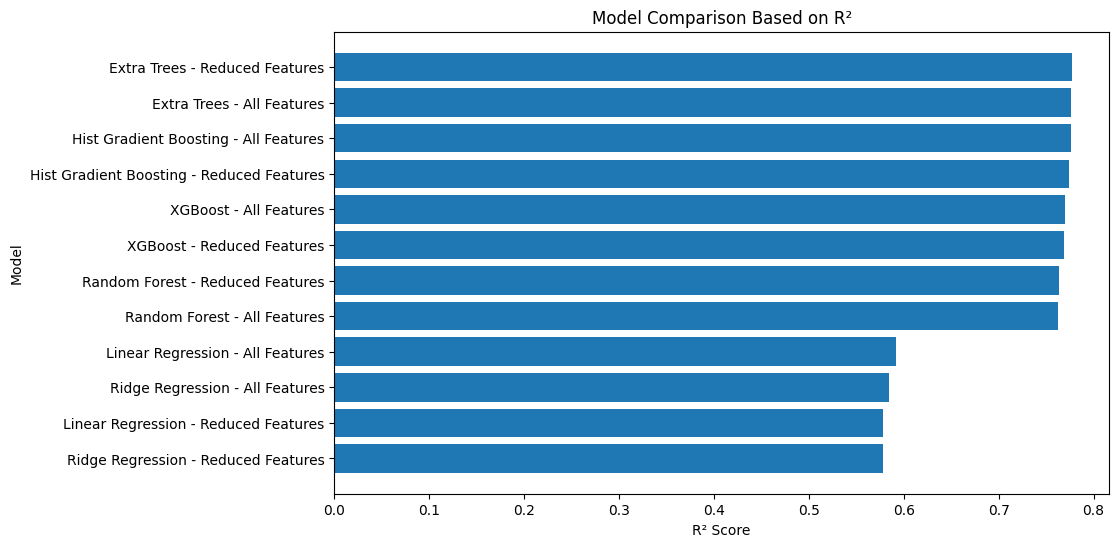

In [138]:
plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["R2"])
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.title("Model Comparison Based on R²")
plt.gca().invert_yaxis()
plt.show()

In [139]:
best_model_name = results_df.iloc[0]["Model"]

print("Best model:")
print(best_model_name)

Best model:
Extra Trees - Reduced Features


> ## Section 7: Detailed Evaluation of the Best Model

In [140]:
model_dict = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42,
        max_iter=200
    )
}

if xgboost_available:
    model_dict["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

In [141]:
if "All Features" in best_model_name:
    feature_set = "all"
else:
    feature_set = "reduced"

base_model_name = best_model_name.replace(" - All Features", "").replace(" - Reduced Features", "")

print("Base model:", base_model_name)
print("Feature set:", feature_set)

Base model: Extra Trees
Feature set: reduced


In [142]:
linear_model_names = ["Linear Regression", "Ridge Regression"]

if feature_set == "all":
    if base_model_name in linear_model_names:
        X_train_best = X_all_train_scaled
        X_test_best = X_all_test_scaled
    else:
        X_train_best = X_all_train
        X_test_best = X_all_test

elif feature_set == "reduced":
    if base_model_name in linear_model_names:
        X_train_best = X_reduced_train_scaled
        X_test_best = X_reduced_test_scaled
    else:
        X_train_best = X_reduced_train
        X_test_best = X_reduced_test

print("X_train_best:", X_train_best.shape)
print("X_test_best:", X_test_best.shape)

X_train_best: (62320, 98)
X_test_best: (15581, 98)


In [143]:
best_model = model_dict[base_model_name]

best_model.fit(X_train_best, y_train)

y_pred_best = best_model.predict(X_test_best)

In [144]:
mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print("Best Model Performance")
print("----------------------")
print("Model:", best_model_name)
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))

Best Model Performance
----------------------
Model: Extra Trees - Reduced Features
MAE: 0.9164
RMSE: 1.3776
R²: 0.7775


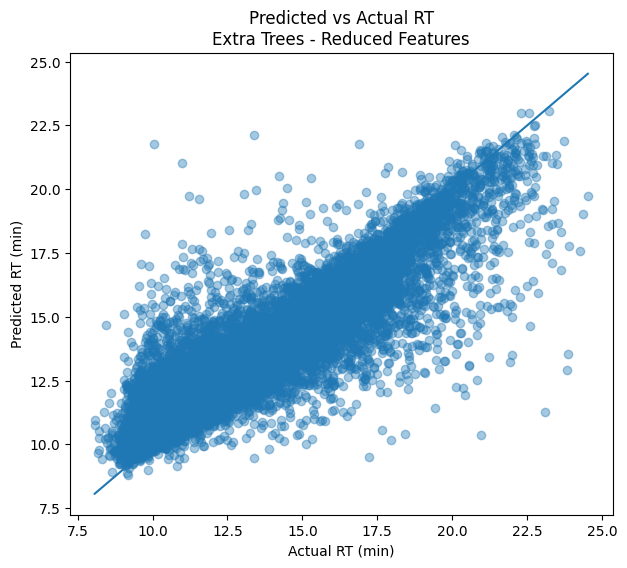

In [145]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4)

min_value = min(y_test.min(), y_pred_best.min())
max_value = max(y_test.max(), y_pred_best.max())

plt.plot([min_value, max_value], [min_value, max_value])

plt.xlabel("Actual RT (min)")
plt.ylabel("Predicted RT (min)")
plt.title(f"Predicted vs Actual RT\n{best_model_name}")
plt.show()

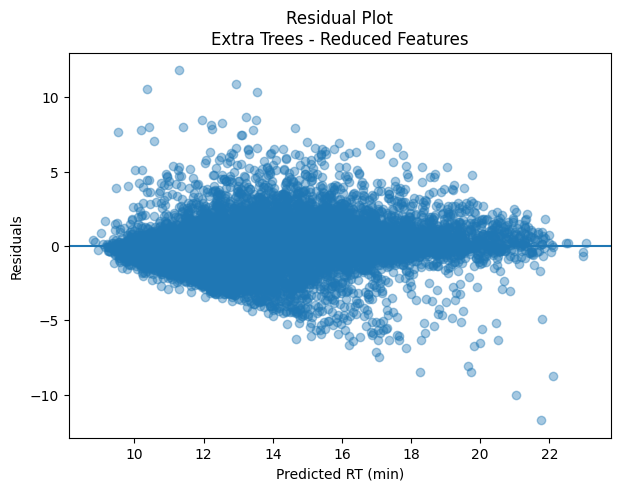

In [147]:
residuals = y_test - y_pred_best

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_best, residuals, alpha=0.4)
plt.axhline(y=0)

plt.xlabel("Predicted RT (min)")
plt.ylabel("Residuals")
plt.title(f"Residual Plot\n{best_model_name}")
plt.show()

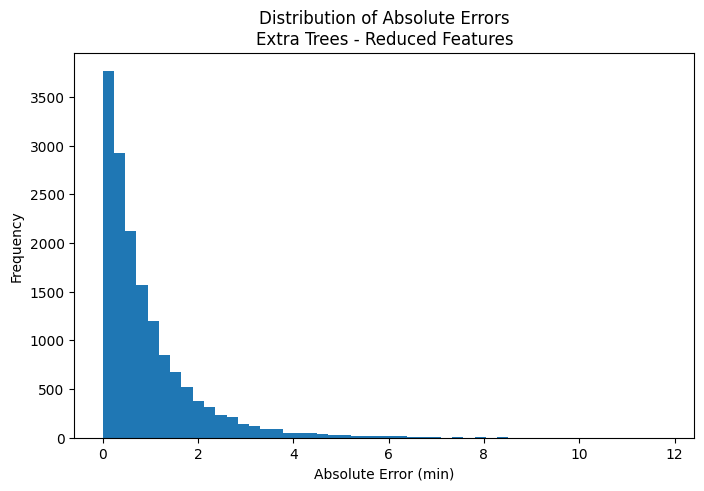

In [148]:
absolute_errors = np.abs(residuals)

plt.figure(figsize=(8, 5))
plt.hist(absolute_errors, bins=50)

plt.xlabel("Absolute Error (min)")
plt.ylabel("Frequency")
plt.title(f"Distribution of Absolute Errors\n{best_model_name}")
plt.show()

In [150]:
# This table shows the worst-predicted molecules.

evaluation_df = pd.DataFrame({
    "actual_rt_min": y_test,
    "predicted_rt_min": y_pred_best,
    "residual": residuals,
    "absolute_error": absolute_errors
})

evaluation_df = evaluation_df.sort_values(by="absolute_error", ascending=False)

evaluation_df.head(20)

,actual_rt_min,predicted_rt_min,residual,absolute_error
70303,23.110,11.285395,11.824605,11.824605
67587,10.045,21.757680,-11.712680,11.712680
15606,23.827,12.926890,10.900110,10.900110
38290,20.962,10.369515,10.592485,10.592485
36047,23.878,13.539290,10.338710,10.338710
16307,10.990,21.024470,-10.034470,10.034470
61884,13.388,22.117695,-8.729695,8.729695
45804,21.928,13.224750,8.703250,8.703250
10430,11.230,19.723255,-8.493255,8.493255
15056,9.765,18.252690,-8.487690,8.487690


> ## Section 8: Model Improvement and Hyperparameter Tuning

The main objective is to tune Extra Trees Regressor using the reduced feature set.


In [151]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

In [154]:
def evaluate_predictions(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [156]:
X_train_tune = X_reduced_train
X_test_tune = X_reduced_test

print("Selected feature set: Reduced Features")
print("X_train_tune:", X_train_tune.shape)
print("X_test_tune:", X_test_tune.shape)

Selected feature set: Reduced Features
X_train_tune: (62320, 98)
X_test_tune: (15581, 98)


In [157]:
baseline_best_result = {
    "Model": "Baseline Extra Trees - Reduced Features",
    "MAE": 0.9164,
    "RMSE": 1.3776,
    "R2": 0.7775
}

baseline_best_df = pd.DataFrame([baseline_best_result])
baseline_best_df

,Model,MAE,RMSE,R2
0,Baseline Extra Trees - Reduced Features,0.9164,1.3776,0.7775


In [158]:
et_model = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1
)

et_param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [False, True]
}

et_search = RandomizedSearchCV(
    estimator=et_model,
    param_distributions=et_param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

et_search.fit(X_train_tune, y_train)

print("Best Extra Trees parameters:")
print(et_search.best_params_)

print("Best CV RMSE:")
print(-et_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


c:\Users\saeed\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
7 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\saeed\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\_utils.py", line 72, in __call__
    return self.func(**kwargs)
           ~~~~~~~~~^^^^^^^^^^
  File "c:\Users\saeed\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
           

Best Extra Trees parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 50, 'bootstrap': False}
Best CV RMSE:
1.457024351848234


In [159]:
et_best = et_search.best_estimator_

et_pred = et_best.predict(X_test_tune)

et_tuned_result = evaluate_predictions(
    "Tuned Extra Trees - Reduced Features",
    y_test,
    et_pred
)

pd.DataFrame([et_tuned_result]).round(4)

,Model,MAE,RMSE,R2
0,Tuned Extra Trees - Reduced Features,0.947,1.3925,0.7727


> ## Section 9: Final Model Interpretation and Feature Importance

In [161]:
final_model = ExtraTreesRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_reduced_train, y_train)

final_pred = final_model.predict(X_reduced_test)

In [162]:
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

final_result = pd.DataFrame([{
    "Model": "Final Extra Trees - Reduced Features",
    "MAE": final_mae,
    "RMSE": final_rmse,
    "R2": final_r2
}])

final_result.round(4)

,Model,MAE,RMSE,R2
0,Final Extra Trees - Reduced Features,0.9164,1.3776,0.7775


In [163]:
feature_importance = pd.DataFrame({
    "Feature": X_reduced_train.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,MolLogP,0.157527
1,NumAromaticCarbocycles,0.056266
2,NHOHCount,0.038051
3,SlogP_VSA2,0.030057
4,PEOE_VSA4,0.024428
5,PEOE_VSA8,0.023596
6,SMR_VSA9,0.023270
7,SMR_VSA3,0.019604
8,PEOE_VSA2,0.018750
9,SMR_VSA6,0.018232


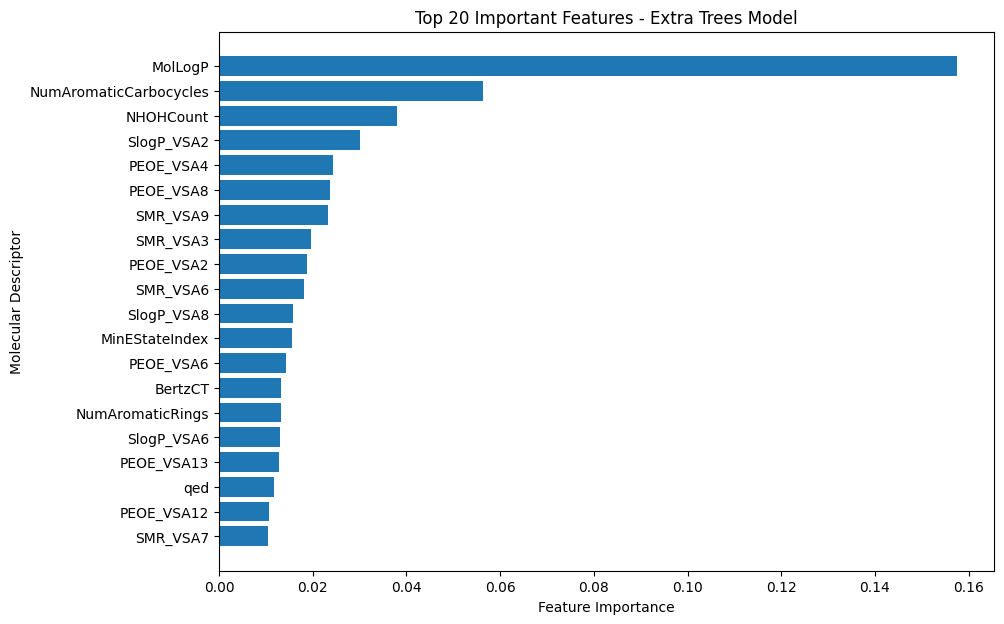

In [164]:
top_n = 20

top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Molecular Descriptor")
plt.title("Top 20 Important Features - Extra Trees Model")
plt.gca().invert_yaxis()
plt.show()

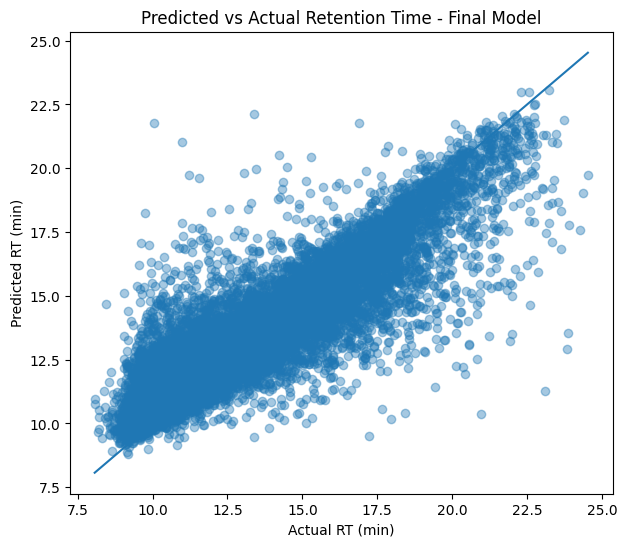

In [165]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_pred, alpha=0.4)

min_value = min(y_test.min(), final_pred.min())
max_value = max(y_test.max(), final_pred.max())

plt.plot([min_value, max_value], [min_value, max_value])

plt.xlabel("Actual RT (min)")
plt.ylabel("Predicted RT (min)")
plt.title("Predicted vs Actual Retention Time - Final Model")
plt.show()

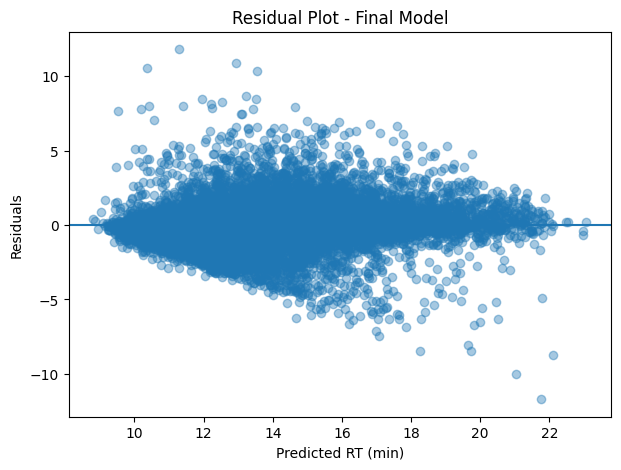

In [166]:
final_residuals = y_test - final_pred

plt.figure(figsize=(7, 5))
plt.scatter(final_pred, final_residuals, alpha=0.4)
plt.axhline(y=0)

plt.xlabel("Predicted RT (min)")
plt.ylabel("Residuals")
plt.title("Residual Plot - Final Model")
plt.show()

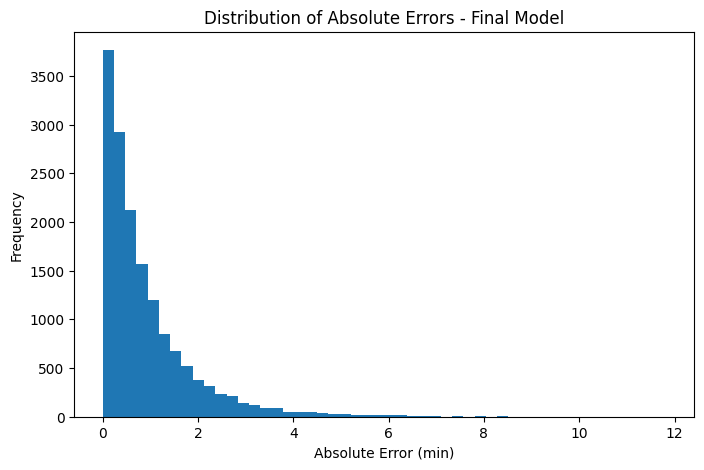

In [167]:
final_absolute_errors = np.abs(final_residuals)

plt.figure(figsize=(8, 5))
plt.hist(final_absolute_errors, bins=50)

plt.xlabel("Absolute Error (min)")
plt.ylabel("Frequency")
plt.title("Distribution of Absolute Errors - Final Model")
plt.show()

In [168]:
final_evaluation_df = pd.DataFrame({
    "actual_rt_min": y_test,
    "predicted_rt_min": final_pred,
    "residual": final_residuals,
    "absolute_error": final_absolute_errors
})

final_evaluation_df = final_evaluation_df.sort_values(
    by="absolute_error",
    ascending=False
)

final_evaluation_df.head(20).round(4)

,actual_rt_min,predicted_rt_min,residual,absolute_error
70303,23.110,11.2854,11.8246,11.8246
67587,10.045,21.7577,-11.7127,11.7127
15606,23.827,12.9269,10.9001,10.9001
38290,20.962,10.3695,10.5925,10.5925
36047,23.878,13.5393,10.3387,10.3387
16307,10.990,21.0245,-10.0345,10.0345
61884,13.388,22.1177,-8.7297,8.7297
45804,21.928,13.2247,8.7033,8.7033
10430,11.230,19.7233,-8.4933,8.4933
15056,9.765,18.2527,-8.4877,8.4877


1. Feature importance

The most important descriptor is clearly: **MolLogP**

This makes chemical sense. In reversed-phase LC, more hydrophobic molecules generally interact more strongly with the stationary phase and therefore often have longer retention times.

2. Predicted vs actual plot

The model shows a clear positive relationship between predicted and actual RT. Most points follow the diagonal trend, which confirms that the model captures the main retention-time pattern.

However, there is some spread, especially at higher RT values.

3. Residual plot

The residuals are mostly centered around zero, which is good.

But the spread is not perfectly uniform. There are larger errors in the mid-to-high predicted RT region.

4. Absolute error distribution

Most errors are small, with a long right tail.

> ## Section 10: Save the Final Model and Prepare for Deployment

In [169]:
import joblib
joblib.dump(final_model, "final_extra_trees_rt_model.pkl")



['final_extra_trees_rt_model.pkl']

In [170]:
selected_features = X_reduced_train.columns.tolist()

joblib.dump(selected_features, "selected_features.pkl")

['selected_features.pkl']

In [171]:
pd.DataFrame({"Feature": selected_features}).to_csv(
    "selected_features.csv",
    index=False
)

>> ## ***Author:*** Sam Pharmed [Kaggle](https://www.kaggle.com/sampharmed), [GitHub](https://github.com/Samb-pharmed)  
>> **Date:** 19 April 2026  
>> **Dataset:** [LCMS Retention Time Dataset](https://www.kaggle.com/datasets/satwikmurarka/meltin-retention-times-with-molecular-descriptors)   